In [7]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [ ]:
class BatsmanState(TypedDict):
    runs : int
    balls : int
    fours : int
    sixes : int
    
    sr : float
    bpb : float
    boundary_pct : float
    
    summary : str

In [16]:
def calculate_sr(state : BatsmanState):
    sr = (state['runs']/state['balls']) * 100
    return {'sr' : sr}

def calculate_bpb(state : BatsmanState):
    bd = state['fours'] + state['sixes']
    bpb = (state['balls'] / bd)
    
    return {'bpb' : bpb}

def calculate_boundary_pct(state : BatsmanState):
    bp = (((state['fours'] * 4) + (state['sixes'] * 6)) / state['runs']) * 100
    return {'boundary_pct' : bp}

def summary(state : BatsmanState):
    summary = f"""
    Strike Rate - {state['sr']} \n
    Balls Per Boundary  - {state['bpb']} \ng
    Boundary Percentage - {state['boundary_pct']}
    """
    
    return {'summary' : summary}

In [17]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_pct', calculate_boundary_pct)
graph.add_node('summary', summary)

# Edges
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_pct')
graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundary_pct', 'summary')
graph.add_edge('summary', END)

workflow = graph.compile()

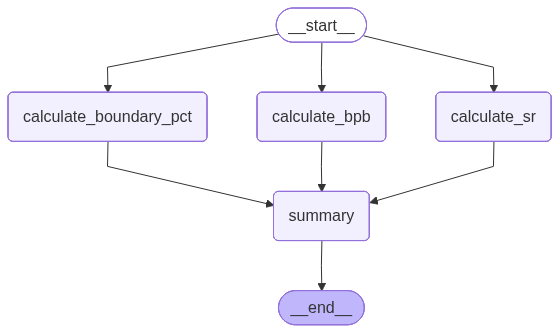

In [18]:
workflow

In [19]:
initial_state = {
    'runs' : 97,
    'balls' : 29,
    'fours' : 5,
    'sixes' : 12 
}

final_state = workflow.invoke(initial_state)
print(final_state)


{'runs': 97, 'balls': 29, 'fours': 5, 'sixes': 12, 'sr': 334.48275862068965, 'bpb': 1.7058823529411764, 'boundary_pct': 94.84536082474226}


# Parallelization workflow
UPSC essay evaluation

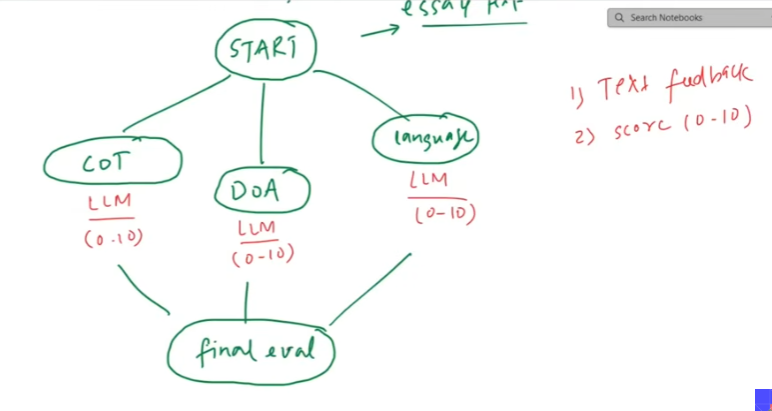

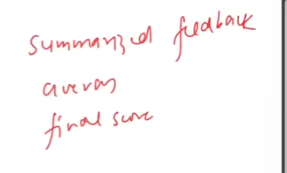

In [32]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_ollama import ChatOllama
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator

load_dotenv()

model = ChatOllama(
    model="llama3",  # or any model you have pulled
    temperature=0
)

In [23]:
class evaluationSchema(BaseModel):
    feedback : str = Field(description = "Detailed feedback for essay")
    score : int = Field(description="Score out og 10", ge=0, le=10)

In [24]:
Structured_model = model.with_structured_output(evaluationSchema)

In [29]:
essay = """
# Artificial Intelligence: Transforming Humanity in the Digital Age

## Introduction

Artificial Intelligence (AI) is one of the most transformative technologies of the twenty-first century. It refers to the ability of machines to perform tasks that traditionally require human intelligence, such as learning, reasoning, decision-making, and problem-solving. From virtual assistants and recommendation systems to autonomous vehicles and advanced medical diagnostics, AI is reshaping economies, governance, and social interactions. As the world enters the Fourth Industrial Revolution, AI has emerged as a critical driver of innovation, productivity, and national competitiveness.

However, like all powerful technologies, AI presents both opportunities and challenges. The task before policymakers is not merely to promote AI but to ensure that its development remains ethical, inclusive, and beneficial to humanity.

## AI as a Catalyst for Economic Growth

Artificial Intelligence has the potential to significantly enhance economic productivity. By automating repetitive tasks, optimizing resource utilization, and enabling data-driven decision-making, AI can increase efficiency across industries. Manufacturing, agriculture, finance, logistics, and retail sectors are already witnessing substantial improvements through AI-powered solutions.

For developing countries like India, AI offers an opportunity to leapfrog traditional development pathways. AI-driven innovations can support startups, generate new employment opportunities, and strengthen India's position in the global digital economy. Government initiatives such as the Digital India Mission and the National Strategy for Artificial Intelligence aim to harness these benefits for inclusive growth.

## Transforming Governance and Public Service Delivery

AI has immense potential in improving governance. Governments can use AI to analyze large datasets, predict policy outcomes, detect fraud, and improve service delivery. In healthcare, AI can assist in disease diagnosis and epidemic prediction. In agriculture, it can help farmers make informed decisions regarding crop selection, irrigation, and pest control.

AI can also contribute to better urban planning through smart city initiatives, efficient traffic management, and optimized energy consumption. By enhancing administrative efficiency and transparency, AI can strengthen public institutions and improve citizen welfare.

## Revolutionizing Education and Healthcare

The education sector is experiencing a paradigm shift due to AI-powered personalized learning systems. These platforms can adapt content according to individual learning styles and capabilities, making education more accessible and effective.

In healthcare, AI-assisted diagnostics, robotic surgeries, and predictive analytics are improving patient outcomes. Early detection of diseases, remote healthcare services, and efficient management of medical records can significantly strengthen healthcare systems, especially in underserved regions.

## Challenges and Ethical Concerns

Despite its immense promise, AI raises several concerns. One major challenge is job displacement due to automation. While AI may create new forms of employment, many traditional jobs may become obsolete, necessitating large-scale reskilling and upskilling initiatives.

Privacy and data protection constitute another significant concern. AI systems rely heavily on vast amounts of data, creating risks of surveillance, misuse of personal information, and violations of individual rights. The concentration of data and technological power in a few corporations may further exacerbate inequalities.

Algorithmic bias is another critical issue. Since AI systems learn from historical data, they may inherit and amplify existing social prejudices related to gender, race, caste, or economic status. Such biases can undermine fairness and justice in decision-making processes.

The emergence of deepfakes, misinformation campaigns, and autonomous weapon systems also raises serious ethical and security concerns. Therefore, technological advancement must be accompanied by robust regulatory frameworks and ethical safeguards.

## India's Approach to Responsible AI

India's approach to AI must be guided by the principles of inclusivity, transparency, accountability, and human dignity. The development of AI should align with constitutional values and the broader objective of social justice.

Investment in digital infrastructure, research and development, quality education, and skill development is essential. Equally important is the formulation of comprehensive legal and ethical frameworks that ensure data protection, algorithmic transparency, and accountability.

India can position itself as a global leader in "Responsible AI" by promoting innovation while safeguarding democratic values and human rights.

## The Way Forward

The future of AI should be human-centric rather than technology-centric. Governments, industries, academia, and civil society must collaborate to ensure that AI serves the collective good. Policies should focus on ethical innovation, digital inclusion, workforce reskilling, and international cooperation.

AI must be viewed not as a substitute for human intelligence but as a tool to augment human capabilities. The ultimate goal should be to create a society where technology empowers individuals, reduces inequalities, and enhances the quality of life for all.

## Conclusion

Artificial Intelligence represents both an unprecedented opportunity and a profound responsibility. Its ability to transform economies, governance, healthcare, and education makes it one of the defining technologies of our era. Yet, its benefits can be fully realized only when innovation is balanced with ethics, regulation, and inclusivity. As India aspires to become a global knowledge and technology leader, the challenge lies not merely in developing advanced AI systems but in ensuring that AI remains aligned with human values and contributes to sustainable and equitable development. In this journey, technology must remain a servant of humanity, not its master.

"""

In [30]:
prompt = f"Evaluate the language quality of the follw=owing essay and provide feedback and assign the score between 0 to 10 : {essay}"
Structured_model.invoke(prompt)

evaluationSchema(feedback='The essay is well-structured and provides a comprehensive overview of the impact of Artificial Intelligence (AI) on various aspects of society. The language is clear and concise, making it easy to follow for readers who may not be familiar with AI. However, there are some areas that could be improved upon.', score=8)

In [36]:
class UPSCState(TypedDict):
    essay : str
    language_feedback : str
    analysis_feedback : str
    clarity_feedback : str

    overall_feedback : str
    individual_scores : Annotated[list[int], operator.add]
    avg_score : float
    

In [37]:
def evaluate_language(state: UPSCState):
    prompt = f"Evaluate the language quality of the follw=owing essay and provide feedback and assign the score between 0 to 10 : {state['essay']}"
    output = Structured_model.invoke(prompt)

    return {'language_feedback' : output.feedback, 'individual_scores': [output.score]}

def evaluate_analysis(state: UPSCState):
    prompt = f"Evaluate the Depth of analysis quality of the follw=owing essay and provide feedback and assign the score between 0 to 10 : {state['essay']}"
    output = Structured_model.invoke(prompt)

    return {'analysis_feedback' : output.feedback, 'individual_scores': [output.score]}

def evaluate_thought(state: UPSCState):
    prompt = f"Evaluate the clarity of thoughts quality of the follw=owing essay and provide feedback and assign the score between 0 to 10 : {state['essay']}"
    output = Structured_model.invoke(prompt)

    return {'clarity_feedback' : output.feedback, 'individual_scores': [output.score]}

def final_evaluation(state: UPSCState):
    # Summary Feedback
    prompt = f'Based on the following feedbacks create a summerized feedback \n language feedback - {state['language_feedback']} \n depth of analysis feedback - {state['analysis_feedback']} \n clarity of thoughts feedback - {state['clarity_feedback']}'
    overall_feedback = model.invoke(prompt).content
    
    # Average score
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])
    return {
        'overall_feedback' : overall_feedback,
        'avg_score' : avg_score
    }


In [38]:
graph = StateGraph(UPSCState)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()


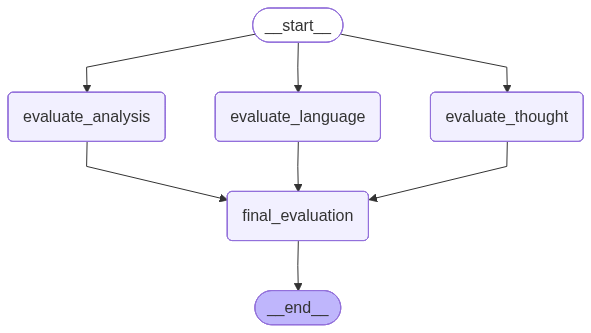

In [39]:
workflow

In [40]:
initial_state = {
    'essay' : essay
}

workflow.invoke(initial_state)

{'essay': '\n# Artificial Intelligence: Transforming Humanity in the Digital Age\n\n## Introduction\n\nArtificial Intelligence (AI) is one of the most transformative technologies of the twenty-first century. It refers to the ability of machines to perform tasks that traditionally require human intelligence, such as learning, reasoning, decision-making, and problem-solving. From virtual assistants and recommendation systems to autonomous vehicles and advanced medical diagnostics, AI is reshaping economies, governance, and social interactions. As the world enters the Fourth Industrial Revolution, AI has emerged as a critical driver of innovation, productivity, and national competitiveness.\n\nHowever, like all powerful technologies, AI presents both opportunities and challenges. The task before policymakers is not merely to promote AI but to ensure that its development remains ethical, inclusive, and beneficial to humanity.\n\n## AI as a Catalyst for Economic Growth\n\nArtificial Intelli

In [41]:
essay2 = """
# Artifical Inteligence Tecnology

Artifical Inteligence is one of the most imporatant tecnology in todays world. It is called AI and it is very populer nowdays. AI means machine can think and work like human beings. Many peoples are using AI for many purpose and it is becoming more and more famouse every day. AI is a gift of science and it is helping peoples in different works.

There are many benifits of AI. Firstly, AI make work easier and faster. Students can use AI for study and doing assingments. Teachers can also use it for teaching students. In hospitals doctors use AI machines for checking deseases and giving treatment. AI is also used in mobile phones, computors and internet. Because of AI, many things become easy and less time consuming.

However, AI also have some disadvantges. AI can take away jobs from many peoples because machines can do work of humans. This can increase unemploiment in the country. AI also sometimes gives wrong informations and peoples may belive it without checking. There is also risk of hacking and cyber crims because AI can be misused by bad peoples. Therefore AI is not always good.

India is also growing in the field of AI. Many companes are investing crores of rupees in AI tecnology. Government is also taking intrest in AI and digital development. AI can help India to become a developed nation in future. But there are many problams like lack of education, poor internet and less awarness in rural areas. So these issues should be solved.

AI is used in many sectors like educasion, helthcare, farming, banking and transportasion. Farmers can use AI for growing crops and increasing production. Banks use AI for customer service and detecting frauds. AI is everywhere and its uses are increasing day by day. It is very useful and also very dangerus at the same time.

Some peoples thinks AI will replace humans fully in future. Other peoples thinks humans are always smarter than machines. It is difficult to say what will happen because future is unknow. AI is changing the world very rapidly and everyone is talking about it. ChatGPT and other AI tools are becoming very populer among students and workers.

In conclution, Artifical Inteligence is a very important tecnology. It has both advatanges and disadvantges. We should use AI carefully and wisely. Government should make proper rules and peoples should use AI only for good purposses. If AI is used correctly it can help mankind, but if it is used wrongly it can create many problams. Therefore AI is good and bad both and we should take care while using it.

"""

In [ ]:
initial_state = {
    'essay' : essay2
}

workflow.invoke(initial_state)

{'essay': '\n# Artifical Inteligence Tecnology\n\nArtifical Inteligence is one of the most imporatant tecnology in todays world. It is called AI and it is very populer nowdays. AI means machine can think and work like human beings. Many peoples are using AI for many purpose and it is becoming more and more famouse every day. AI is a gift of science and it is helping peoples in different works.\n\nThere are many benifits of AI. Firstly, AI make work easier and faster. Students can use AI for study and doing assingments. Teachers can also use it for teaching students. In hospitals doctors use AI machines for checking deseases and giving treatment. AI is also used in mobile phones, computors and internet. Because of AI, many things become easy and less time consuming.\n\nHowever, AI also have some disadvantges. AI can take away jobs from many peoples because machines can do work of humans. This can increase unemploiment in the country. AI also sometimes gives wrong informations and people

: 